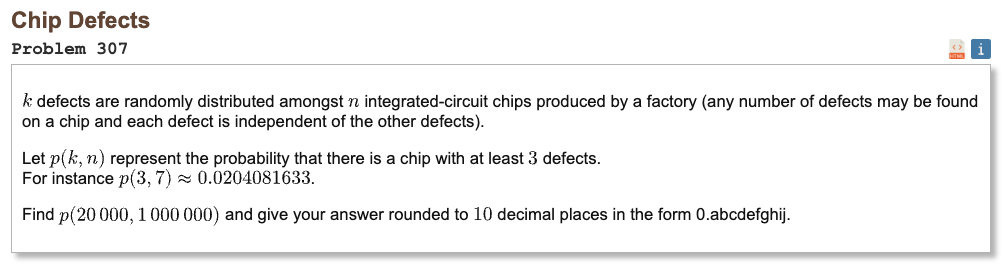

## Initial approach

* count the safer opposite case first, where every chip has at most two defects
* split that safe case by how many chips receive exactly two defects
* the remaining defects must each go to different chips
* use logarithms because the factorial values are far too large
* sum the safe probabilities carefully to avoid numerical overflow
* subtract the safe probability from 1
* round the final answer to 10 decimal places

In [1]:
import mpmath as mp

def solve(defects, chips):
    mp.mp.dps = 80

    log_terms = []
    log_defects_factorial = mp.loggamma(defects + 1)
    log_total = defects * mp.log(chips)

    for pairs in range(defects // 2 + 1):
        singles = defects - 2 * pairs
        empty = chips - defects + pairs

        log_term = (
            mp.loggamma(chips + 1)
            - mp.loggamma(pairs + 1)
            - mp.loggamma(singles + 1)
            - mp.loggamma(empty + 1)
            + log_defects_factorial
            - pairs * mp.log(2)
            - log_total
        )

        log_terms.append(log_term)

    max_log = max(log_terms)
    safe_probability = mp.e ** max_log * mp.fsum(mp.e ** (x - max_log) for x in log_terms)

    return 1 - safe_probability


In [2]:
%%time
result = solve(20000, 1000000)
print("Result:", f"{float(result):.10f}")

Result: 0.7311720251
CPU times: user 557 ms, sys: 3.22 ms, total: 561 ms
Wall time: 560 ms
